<a href="https://colab.research.google.com/github/timothyow/MMM_01/blob/main/MMM_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

In [6]:
file_path = '/content/TH_FM_OMG_MMM_20250517.csv'
df = pd.read_csv(file_path)
display(df.head())

,country_code,market,month_yyyymm,category_group,category,brand,sales_value,sales_volume,wd_tdp_reg,weighted_wd_reg,...,nd_max_reg_prem_l01,avg_price_reg_l01,avg_price_prem_l01,avg_price_reg_prem_l01,market_avg_price_l01,hiq_avg_price_l01,price_reg_prem_mkt_idx_l01,cpi_2019_l01,sales_value_l01,sales_volume_l01
0,THA,TOTAL THAILAND+MTSR,2021-05-01,RTD,KIDS MILK,FOREMOST OMEGA REGULAR & PREMIUM,191764897.28,3627541.81,549.77,37.26,...,22.57,50.96,76.92,51.72,81.51,94.86,0.63,1.55,210278898.59,4065903.17
1,THA,TOTAL THAILAND+MTSR,2021-06-01,RTD,KIDS MILK,FOREMOST OMEGA REGULAR & PREMIUM,187777921.15,3577009.45,533.02,39.60,...,22.51,51.89,79.70,52.86,81.76,92.99,0.65,0.05,191764897.28,3627541.81
2,THA,TOTAL THAILAND+MTSR,2021-07-01,RTD,KIDS MILK,FOREMOST OMEGA REGULAR & PREMIUM,161519864.59,2960911.60,515.77,35.83,...,22.41,51.28,80.89,52.50,80.87,94.05,0.65,0.53,187777921.15,3577009.45
3,THA,TOTAL THAILAND+MTSR,2021-08-01,RTD,KIDS MILK,FOREMOST OMEGA REGULAR & PREMIUM,174571694.70,3312366.48,528.73,35.26,...,21.28,53.09,82.59,54.55,82.62,98.52,0.66,0.44,161519864.59,2960911.60
4,THA,TOTAL THAILAND+MTSR,2021-09-01,RTD,KIDS MILK,FOREMOST OMEGA REGULAR & PREMIUM,152577829.26,2886149.44,518.99,37.07,...,20.22,51.21,83.07,52.70,80.85,90.91,0.65,0.00,174571694.70,3312366.48


In [7]:
# 2. Combine Regular & Premium Costs

media_channels = ['TV', 'FACEBOOK', 'YOUTUBE', 'TIKTOK', 'GDN']
for ch in media_channels:
    df[f'COST_{ch}'] = df[f'COST_{ch}_REG'] + df.get(f'COST_{ch}_PREM', 0)

In [8]:
# 3. Transformations: Adstock + Hill Saturation

def adstock(x, alpha=0.5):
    result = np.zeros_like(x)
    for t in range(len(x)):
        result[t] = x[t] + alpha * result[t-1] if t > 0 else x[t]
    return result

def hill_saturation(x, alpha=0.8, beta=0.5):
    return (x ** alpha) / (beta ** alpha + x ** alpha)

for ch in media_channels:
    df[f'{ch}_trans'] = hill_saturation(adstock(df[f'COST_{ch}'].values))

In [17]:
# 4. Prepare Features & Target

X = df[[f'{ch}_trans' for ch in media_channels] + ['avg_price_reg', 'wd_tdp_reg' ]] #'TREND'
y = np.log(df['sales_value'])

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [25]:
# 5. Fit Linear Regression - sklearn does not have comprehensive model summary
# model = LinearRegression()
# model.fit(X_scaled, y)


# Add a constant to the features for statsmodels
X_scaled_sm = sm.add_constant(X_scaled)

# Create a DataFrame with column names for better summary readability
X_scaled_sm_df = pd.DataFrame(X_scaled_sm, columns=['const'] + list(X.columns))

# Fit the OLS model
model_sm = sm.OLS(y, X_scaled_sm_df).fit()

# Print the summary
print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:            sales_value   R-squared:                       0.885
Model:                            OLS   Adj. R-squared:                  0.863
Method:                 Least Squares   F-statistic:                     39.57
Date:                Wed, 22 Oct 2025   Prob (F-statistic):           4.84e-15
Time:                        07:50:03   Log-Likelihood:                 53.556
No. Observations:                  44   AIC:                            -91.11
Df Residuals:                      36   BIC:                            -76.84
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             19.2363      0.012   1611.

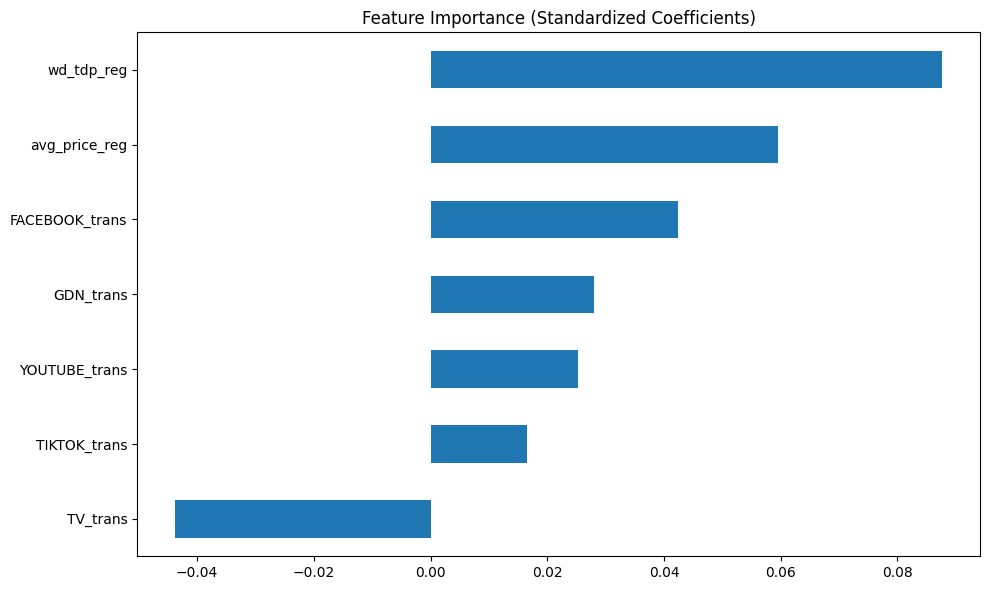

In [32]:
# 6. Feature Importance (Standardized Coefficients)
importance = pd.Series(model_sm.params[1:], index=X.columns) # Exclude the constant term
plt.figure(figsize=(10, 6))
importance.sort_values().plot(kind='barh', title='Feature Importance (Standardized Coefficients)')
plt.tight_layout()
plt.show()

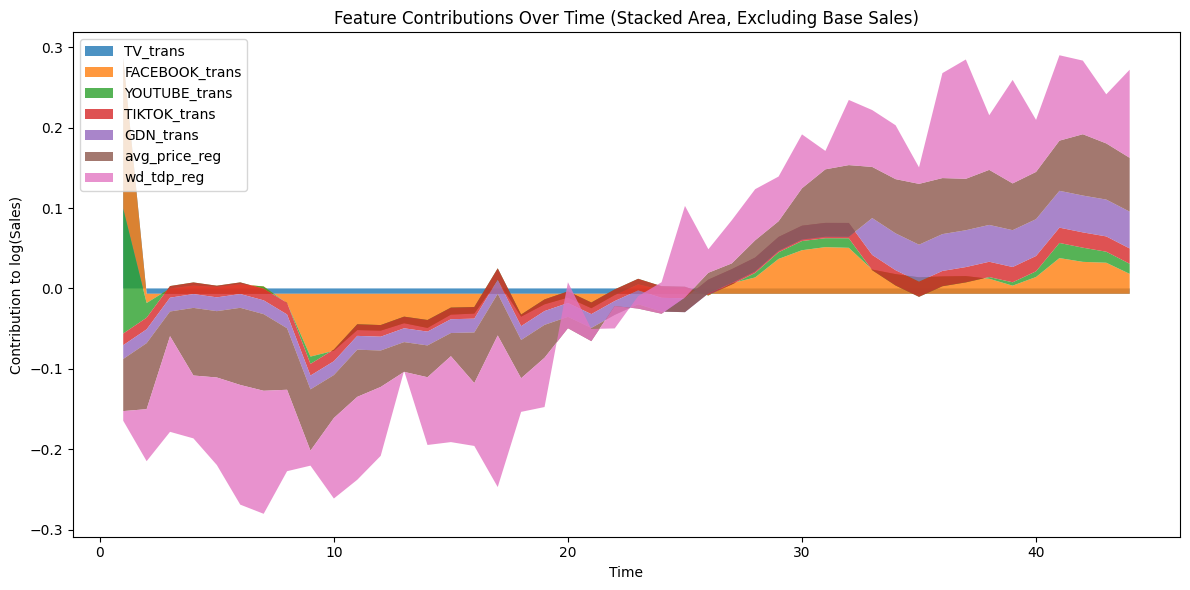

In [41]:
# 7. Contribution Over Time - Features only (Stacked)
# =========================================
# Use coefficients from statsmodels model
# Ensure correct multiplication and DataFrame creation
contributions = pd.DataFrame(X_scaled * model_sm.params[1:].values, columns=X.columns, index=df.index)

# Check if 'TREND' column exists, otherwise use index as time proxy
if 'TREND' in df.columns:
    contributions['Time'] = df['TREND']
else:
    contributions['Time'] = df.index.to_numpy() # Use index as time, convert to numpy array


plt.figure(figsize=(12, 6))
# Stack only the feature columns
plt.stackplot(contributions['Time'], contributions[X.columns].T, labels=X.columns, alpha=0.8)
plt.title('Feature Contributions Over Time (Stacked Area, Excluding Base Sales)')
plt.xlabel('Time')
plt.ylabel('Contribution to log(Sales)')
plt.legend(loc='upper left') # Adjust legend location for better visibility
plt.tight_layout()
plt.show()

In [46]:
# Re-calculate contributions DataFrame
contributions = pd.DataFrame(X_scaled * model_sm.params[1:].values, columns=X.columns, index=df.index)

# Separate positive and negative contributions
positive_contributions = contributions.clip(lower=0)
negative_contributions = contributions.clip(upper=0)

# Sum positive and negative contributions across features for each time point
total_positive_contribution = positive_contributions.sum(axis=1)
total_negative_contribution = negative_contributions.sum(axis=1)

# Check if 'TREND' column exists, otherwise use index as time proxy
if 'TREND' in df.columns:
    time_index = df['TREND']
else:
    time_index = df.index.to_numpy() # Use index as time, convert to numpy array

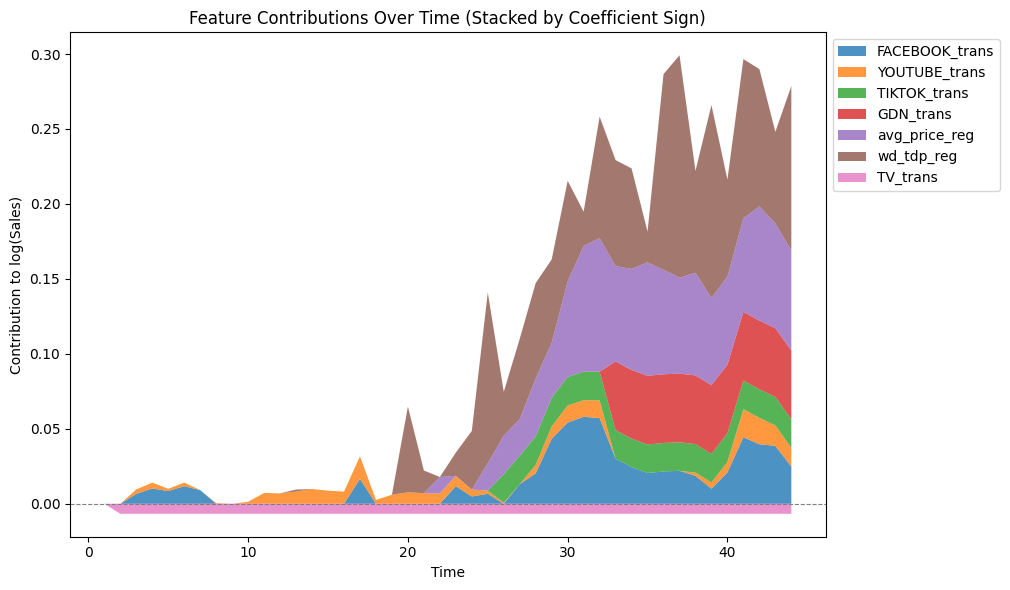

In [48]:
# Identify features with positive and negative coefficients (excluding the constant)
feature_coefficients = model_sm.params[1:]
positive_coef_features = feature_coefficients[feature_coefficients >= 0].index.tolist()
negative_coef_features = feature_coefficients[feature_coefficients < 0].index.tolist()

plt.figure(figsize=(12, 6))

# Plot positive contributions stacked above 0
if positive_coef_features: # Check if there are any features with positive coefficients
    # Use the positive_contributions DataFrame for stacking features with positive coefficients
    plt.stackplot(time_index, positive_contributions[positive_coef_features].T, labels=[f'{col}' for col in positive_coef_features], alpha=0.8)

# Plot negative contributions stacked below 0
if negative_coef_features: # Check if there are any features with negative coefficients
    # Use the negative_contributions DataFrame for stacking features with negative coefficients
    plt.stackplot(time_index, negative_contributions[negative_coef_features].T, labels=[f'{col}' for col in negative_coef_features], alpha=0.8)


plt.title('Feature Contributions Over Time (Stacked by Coefficient Sign)')
plt.xlabel('Time')
plt.ylabel('Contribution to log(Sales)')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1)) # Adjust legend position
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8) # Add a horizontal line at 0
plt.tight_layout(rect=[0, 0, 0.85, 1]) # Adjust layout to make space for legend
plt.show()